<a href="https://colab.research.google.com/github/HafizRizqi/MachineLearning_2026/blob/main/JS06/JS06_TUGAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📶Tugas Lab

1. Buatlah model SVM dengan menggunakan data voice.csv dengan ketentuan,

    a. Split data dengan rasio 70:30 dan 80:20 untuk setiap model yang akan dibangun.

      i. Gunakan model dengan kernel linier.

      ii. Gunakan model dengan kernel polynomial.

      iii. Gunakan model dengan kernel RBF.

    b. Tabulasikan performansi setiap split dan kernel berdasarkan metrik akurasi.
  2. Gunakan data pada praktikum 5 untuk membuat model klasifikasi siang dan malam menggunakan SVM dengan kernel RBF menggunakan fitur histrogram. Gunakan rasio 80:20. Anda dapat bereksperimen dengan hyperparameter tunning dari kernel RBF. Catat performansi akurasinya!

# NOMOR 1

a. Import Library

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

b. Load dataset

In [4]:
from google.colab import files
uploaded = files.upload()

Saving voice (1).csv to voice (1).csv


In [5]:
df = pd.read_csv('voice (1).csv')

print("Shape data:", df.shape)
display(df.head())

Shape data: (3168, 21)


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


Dataset digunakan sebagai sumber data untuk membangun model klasifikasi SVM. Pada dataset ini terdapat 3.168 data dengan 20 fitur suara dan satu kolom label.

c. Encoding Data

In [7]:
# Encoding data label
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['label'] = le.fit_transform(df['label'])

df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,1
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,1
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,1
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,1
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,1


d. Pisahkan Fitur dan Target

In [8]:
# Memisahkan fitur dan target
X = df.drop('label', axis=1)
y = df['label']

print("Data fitur:")
display(X.head())

print("Data target:")
display(y.head())

Data fitur:


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,0.000000,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,0.000000,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,0.000000,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,0.083878,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,0.104261,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274


Data target:


,label
0,1
1,1
2,1
3,1
4,1


Kolom label menjadi target klasifikasi, sedangkan 20 kolom lainnya menjadi fitur yang digunakan oleh SVM. Label terdiri dari dua kelas, yaitu male dan female.

e. Buat model SVM untuk semua split dan kernel

Karena skala fitur pada voice.csv berbeda-beda, saya menggunakan StandardScaler sebelum SVM. Ini penting terutama untuk kernel polynomial dan RBF.

In [13]:
hasil = []

for split, test_size in [("70:30", 0.30), ("80:20", 0.20)]:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    for kernel in ["linear", "poly", "rbf"]:

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel=kernel))
        ])

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)

        hasil.append({
            "Split": split,
            "Kernel": kernel,
            "Akurasi": accuracy
        })

e. Menampilkan Tabel hasil kernel (linear, Polynomial,Rbf)

In [14]:
hasil_df = pd.DataFrame(hasil)

hasil_df["Akurasi (%)"] = hasil_df["Akurasi"] * 100

hasil_df = hasil_df.drop("Akurasi", axis=1)

hasil_df

,Split,Kernel,Akurasi (%)
0,70:30,linear,97.896951
1,70:30,poly,96.004206
2,70:30,rbf,98.317560
3,80:20,linear,97.476341
4,80:20,poly,95.583596
5,80:20,rbf,98.264984


# Analisa hasil
Berdasarkan hasil percobaan, ketiga kernel SVM mampu menghasilkan akurasi yang cukup tinggi pada dataset voice.csv.

Kernel RBF memberikan hasil terbaik pada kedua rasio pembagian data. Pada split 70:30, akurasinya mencapai 98.317%, sedangkan pada split 80:20 mencapai 98.26%. Hasil ini menunjukkan bahwa RBF paling baik dalam menangani pola hubungan fitur suara pada dataset yang digunakan.

Kernel Linear juga memberikan performa yang tinggi, yaitu 97.89% pada split 70:30 dan 97.476% pada split 80:20. Sementara itu, kernel Polynomial memperoleh akurasi paling rendah dibandingkan kedua kernel lainnya, yaitu 96.00% dan 95.58%.

Menariknya, pada dataset ini perubahan rasio split dari 70:30 menjadi 80:20 tidak menyebabkan peningkatan akurasi. Hal tersebut menunjukkan bahwa performa model relatif stabil terhadap kedua pembagian data yang digunakan.

# Kesimpulan
Berdasarkan percobaan enam model SVM, yaitu tiga kernel dengan dua rasio split, kernel RBF merupakan model dengan performa terbaik berdasarkan metrik akurasi. Akurasi tertinggi diperoleh pada split 70:30 sebesar 98.317%, sehingga model SVM dengan kernel RBF dapat dipilih sebagai model terbaik pada percobaan ini.



# NOMOR 2

a. Import Library

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

b. Load Dataset

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
train_dir = "drive/MyDrive/images/training/"
test_dir = "drive/MyDrive/images/test/"

c. Load Gambar

In [21]:
def load_dataset(img_dir):
    p = Path(img_dir)
    img_list = []

    for folder in p.glob("*"):
        if folder.is_dir():

            label = folder.name

            for file in folder.glob("*.jpg"):
                img = cv2.imread(str(file))

                if img is not None:
                    img_list.append((img, label))

    return img_list

In [22]:
train_data = load_dataset(train_dir)
test_data = load_dataset(test_dir)

print("Jumlah data training:", len(train_data))
print("Jumlah data testing :", len(test_data))

Jumlah data training: 240
Jumlah data testing : 160


d. Menggabungkan Data

In [23]:
data = train_data + test_data

print("Total data:", len(data))

Total data: 400


In [24]:
# Pisahkan gambar dan label
images = [item[0] for item in data]
labels = [item[1] for item in data]

print("Jumlah gambar:", len(images))
print("Jumlah label :", len(labels))

Jumlah gambar: 400
Jumlah label : 400


e. Pra Pengolahan Data

Pada tahap ini ukuran seluruh citra diseragamkan menjadi 1100 × 600 piksel, melakukan prepocesing. Label juga dipertahankan menggunakan aturan `day = 1` dan `night = 0`.

In [31]:
# Menstandarkan ukuran gambar
def standarized_input(image):
    return cv2.resize(image, (1100, 600))


# Encoding label: day = 1, night = 0
def label_encoder(label):
    return 1 if label.lower() == 'day' else 0


# Preprocessing seluruh gambar
data_preprocessed = []

for image, label in data:
    std_img = standarized_input(image)
    encoded_label = label_encoder(label)
    data_preprocessed.append((std_img, encoded_label))

print('Jumlah data setelah preprocessing:', len(data_preprocessed))
print('Ukuran contoh gambar:', data_preprocessed[0][0].shape)

Jumlah data setelah preprocessing: 400
Ukuran contoh gambar: (600, 1100, 3)


f. Ekstraksi Fitur Histogram V-HSV


In [32]:
def extract_histogram_feature(img_list, bins=64):
    features = []
    labels = []

    for image, label in img_list:
        # Karena gambar dibaca dengan cv2.imread(), formatnya BGR
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

        # Ambil channel V / brightness
        v_channel = hsv[:, :, 2]

        # Hitung histogram V
        hist = cv2.calcHist(
            [v_channel],
            [0],
            None,
            [bins],
            [0, 256]
        ).flatten()

        # Normalisasi histogram
        hist = hist / (hist.sum() + 1e-8)

        features.append(hist)
        labels.append(label)

    return np.array(features), np.array(labels)


X_hist, y_hist = extract_histogram_feature(data_preprocessed, bins=64)

print('Shape fitur histogram:', X_hist.shape)
print('Shape target:', y_hist.shape)
print('Jumlah fitur per gambar:', X_hist.shape[1])


Shape fitur histogram: (400, 64)
Shape target: (400,)
Jumlah fitur per gambar: 64


cek salah satu histogram

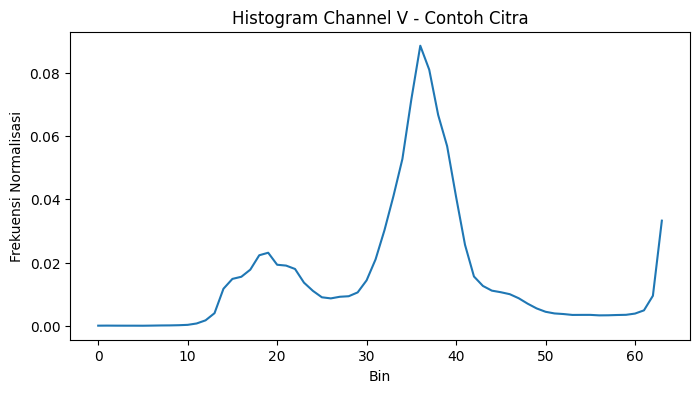

Index gambar: 258
Label: day


In [33]:
# Tampilkan histogram dari satu citra secara acak
rand_idx = np.random.randint(0, len(data_preprocessed))

plt.figure(figsize=(8, 4))
plt.plot(X_hist[rand_idx])
plt.title('Histogram Channel V - Contoh Citra')
plt.xlabel('Bin')
plt.ylabel('Frekuensi Normalisasi')
plt.show()

print('Index gambar:', rand_idx)
print('Label:', 'day' if y_hist[rand_idx] == 1 else 'night')

g. Split Data 80:20

Seluruh 400 data dari praktikum 5 dibagi ulang menggunakan rasio 80:20. stratify digunakan agar proporsi kelas siang dan malam tetap terjaga pada data training dan testing.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hist,
    y_hist,
    test_size=0.20,
    random_state=42,
    stratify=y_hist
)

print('Jumlah data training:', X_train.shape[0])
print('Jumlah data testing :', X_test.shape[0])
print('Rasio split         : 80:20')

Jumlah data training: 320
Jumlah data testing : 80
Rasio split         : 80:20


h. Hyperparameter Tuning SVM Kernel RBF

Model menggunakan kernel RBF. Parameter yang diuji adalah C dan gamma. Standardisasi fitur dilakukan di dalam pipeline agar proses tuning tidak mengalami data leakage.

In [35]:
# Pipeline SVM RBF
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf'))
])

# Kombinasi hyperparameter yang dicoba
param_grid = {
    'svm__C': [0.1, 1, 10, 100, 1000],
    'svm__gamma': ['scale', 0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print('Parameter terbaik:', grid.best_params_)
print(f'Akurasi CV terbaik: {grid.best_score_ * 100:.2f}%')


Parameter terbaik: {'svm__C': 10, 'svm__gamma': 'scale'}
Akurasi CV terbaik: 99.06%


i. Mencatat Performansi Hyperparameter Tuning

In [36]:
tuning_df = pd.DataFrame(grid.cv_results_)[[
    'param_svm__C',
    'param_svm__gamma',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].copy()

tuning_df.columns = [
    'C',
    'Gamma',
    'Mean CV Accuracy',
    'Std CV Accuracy',
    'Rank'
]

tuning_df['Akurasi CV (%)'] = (
    tuning_df['Mean CV Accuracy'] * 100
).round(2)

tuning_df = tuning_df.sort_values('Rank')

display(tuning_df)


,C,Gamma,Mean CV Accuracy,Std CV Accuracy,Rank,Akurasi CV (%)
10,10.0,scale,0.990625,0.007655,1,99.06
15,100.0,scale,0.987500,0.006250,2,98.75
20,1000.0,scale,0.987500,0.006250,2,98.75
17,100.0,0.01,0.987500,0.006250,2,98.75
22,1000.0,0.01,0.987500,0.006250,2,98.75
12,10.0,0.01,0.984375,0.000000,6,98.44
5,1.0,scale,0.981250,0.006250,7,98.12
8,1.0,0.1,0.978125,0.012500,8,97.81
16,100.0,0.001,0.978125,0.012500,8,97.81
7,1.0,0.01,0.978125,0.007655,8,97.81


j. Evaluasi Model Terbaik pada Data Testing

Model dengan kombinasi C dan gamma terbaik digunakan untuk memprediksi data testing yang berjumlah 20% dari seluruh data.

In [37]:
best_model = grid.best_estimator_

# Prediksi data testing
y_pred = best_model.predict(X_test)

# Hitung akurasi
test_accuracy = accuracy_score(y_test, y_pred)

print('===== HASIL AKHIR =====')
print('Kernel                : RBF')
print('Fitur                 : Histogram V HSV (64 bin)')
print('Rasio split           : 80:20')
print('C terbaik             :', grid.best_params_['svm__C'])
print('Gamma terbaik         :', grid.best_params_['svm__gamma'])
print(f'Akurasi cross-validation: {grid.best_score_ * 100:.2f}%')
print(f'Akurasi testing       : {test_accuracy * 100:.2f}%')

===== HASIL AKHIR =====
Kernel                : RBF
Fitur                 : Histogram V HSV (64 bin)
Rasio split           : 80:20
C terbaik             : 10
Gamma terbaik         : scale
Akurasi cross-validation: 99.06%
Akurasi testing       : 100.00%


k. Tabulasi Performansi Akhir

In [38]:
hasil_akhir = pd.DataFrame({
    'Rasio Split': ['80:20'],
    'Fitur': ['Histogram V HSV (64 bin)'],
    'Kernel': ['RBF'],
    'C Terbaik': [grid.best_params_['svm__C']],
    'Gamma Terbaik': [grid.best_params_['svm__gamma']],
    'Akurasi CV (%)': [round(grid.best_score_ * 100, 2)],
    'Akurasi Testing (%)': [round(test_accuracy * 100, 2)]
})

display(hasil_akhir)

,Rasio Split,Fitur,Kernel,C Terbaik,Gamma Terbaik,Akurasi CV (%),Akurasi Testing (%)
0,80:20,Histogram V HSV (64 bin),RBF,10,scale,99.06,100.0


# Analisa Hasil Nomor 2
Pada percobaan ini digunakan 400 citra dari praktikum JS06-05 yang terdiri dari data training dan testing sebelumnya. Karena tugas meminta rasio 80:20, seluruh data digabungkan kemudian dibagi ulang menjadi data training sebesar 80% dan data testing sebesar 20%.

Fitur yang digunakan adalah histogram channel V pada ruang warna HSV sebanyak 64 bin. Penggunaan histogram membuat informasi kecerahan yang digunakan model tidak hanya berupa satu nilai rata-rata seperti AVG_BRIGHT pada JS06-05, tetapi berupa distribusi tingkat kecerahan piksel pada setiap citra.

Model yang digunakan adalah SVM dengan kernel RBF. Hyperparameter C dan gamma diuji menggunakan GridSearchCV dengan 5-fold cross-validation. Kombinasi dengan nilai akurasi cross-validation tertinggi dipilih sebagai model terbaik.

Performansi akhir model dicatat menggunakan akurasi pada data testing 20%. Nilai akurasi testing tersebut menjadi ukuran utama kemampuan model dalam membedakan citra siang dan malam pada data yang belum pernah digunakan saat training.

# Kesimpulan Nomor 2
Model SVM dengan kernel RBF berhasil digunakan untuk klasifikasi citra siang dan malam menggunakan fitur histogram channel V HSV dengan rasio pembagian data 80:20. Hyperparameter C dan gamma dituning untuk memperoleh konfigurasi terbaik. Performansi akhir model ditentukan berdasarkan akurasi pada data testing 20%.

Setelah notebook dijalankan, nilai C, gamma, akurasi cross-validation, dan terutama akurasi testing dari output dapat dicatat sebagai hasil akhir percobaan.